# Lab 7: Machine Learning for Anomalous Property Classification

HMSPIA is a government agency tasked with investigating properties exhibiting behaviour inconsistent with known physical laws. It budget is mostly spent on tea and biscuits. According to rumors, its headquarters is itself haunted. In this lab, we are going to work with a database provided by the authority. 

**National Anomalous Property Register (NAPR)**: The NAPR is a dataset of properties under investigation, classified as:

- **Active:** A file has been opened (often reluctantly).
- **Suspended:** A file was opened and then discreetly set aside (usually after the investigating officer requested a transfer).

---

In this lab, we are going to train a classification model to predict whether a property is:

- **`haunted = True`** (genuinely anomalous).
- **`haunted = False`** (of notable character but not supernatural).

---
Let's get started before the data starts moving by itself.

## 1. Environment Setup

In [1]:
!pip install pyspark matplotlib seaborn scikit-learn "nbformat>=4.2.0"

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, lit, size, split
from pyspark.sql.types import IntegerType

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, Normalizer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# sklearn is only used for roc_curve() — a utility function that operates on
# small Python lists extracted from Spark, not on the full dataset
from sklearn.metrics import roc_curve, auc

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("HMSPIA_NAPR_ML") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/19 13:03:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/19 13:03:36 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/04/19 13:03:36 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


## 2. Loading the Dataset

The NAPR is stored as a Parquet file. Parquet is a columnar binary format that is significantly faster to read than CSV for analytical workloads — Spark only reads the columns it needs, and type information is stored in the file itself so schema inference is exact rather than guessed.

In a production HMSPIA environment this would read from a distributed file system (HDFS, S3, or the Agency's own storage layer, whose location is classified).

In [3]:
properties = spark.read.parquet("haunted_houses.parquet")  # update path as needed

In [ ]:
# Display schema so we know exactly which columns and types we are dealing with
properties.printSchema()

root
 |-- unique_haunt_identifier: string (nullable = true)
 |-- location: string (nullable = true)
 |-- phenomenon_type: string (nullable = true)
 |-- name: string (nullable = true)
 |-- construction_date: long (nullable = true)
 |-- sightings: string (nullable = true)
 |-- owl_hoots: double (nullable = true)
 |-- villagers_count: long (nullable = true)
 |-- warning: boolean (nullable = true)
 |-- teenage_group_disappearance: boolean (nullable = true)
 |-- ghost: string (nullable = true)
 |-- foggy: boolean (nullable = true)
 |-- belltower: boolean (nullable = true)
 |-- moor_nearby: boolean (nullable = true)
 |-- disappeared_visitors: long (nullable = true)
 |-- dread: double (nullable = true)
 |-- tripadvisor_stars: double (nullable = true)
 |-- cursed_ground_type: string (nullable = true)
 |-- insurance_exclusion_clauses: long (nullable = true)
 |-- previous_owners_fate: string (nullable = true)
 |-- archaeology_report_status: string (nullable = true)
 |-- estate_agent_euphemism: s

In [5]:
# Preview a sample — split across logical column groups for readability

# Identifiers and location
properties.select("unique_haunt_identifier", "name", "location",
                  "construction_date", "phenomenon_type").show(3, truncate=50)

# Quantitative indicators
properties.select(
    "owl_hoots", "villagers_count", "disappeared_visitors",
    "dread", "insurance_exclusion_clauses"
).show(3)

# Binary flags
properties.select(
    "warning", "teenage_group_disappearance",
    "foggy", "belltower", "moor_nearby", "haunted"
).show(3)

# Categorical and provenance
properties.select(
    "ghost", "cursed_ground_type", "previous_owners_fate", "archaeology_report_status"
).show(3, truncate=50)

+------------------------------------+-----------------+----------------+-----------------+-------------------+
|             unique_haunt_identifier|             name|        location|construction_date|    phenomenon_type|
+------------------------------------+-----------------+----------------+-----------------+-------------------+
|ed8e734d-ca35-4b7b-b9b6-2f15d71fa7a4|Heatherside Place|         Dervaig|             1704|     hallucinations|
|8900d819-3aee-4100-a3f5-f88080a0f4f6|  Ashenmoor Folly|Kyle of Lochalsh|             1327|frequent nightmares|
|71298717-20a3-4895-93ae-5bc1bbba3580|  Everwood Gables|       Uttoxeter|             1374|           haunting|
+------------------------------------+-----------------+----------------+-----------------+-------------------+
only showing top 3 rows
+------------------+---------------+--------------------+------------------+---------------------------+
|         owl_hoots|villagers_count|disappeared_visitors|             dread|insurance_e

## 3. Dealing with Missing Values

Before any analysis we verify data completeness. Missing values in the NAPR may reflect a genuine absence of phenomena, a failure to complete the field report, or the disappearance of the field officer.

In [6]:
# Count null values across all columns
properties.select(
    [count(when(col(c).isNull(), c)).alias(c) for c in properties.columns]
).show(vertical=True)

26/04/19 13:03:44 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


-RECORD 0--------------------------
 unique_haunt_identifier     | 0   
 location                    | 0   
 phenomenon_type             | 0   
 name                        | 0   
 construction_date           | 0   
 sightings                   | 0   
 owl_hoots                   | 0   
 villagers_count             | 0   
 warning                     | 0   
 teenage_group_disappearance | 0   
 ghost                       | 0   
 foggy                       | 0   
 belltower                   | 0   
 moor_nearby                 | 0   
 disappeared_visitors        | 0   
 dread                       | 0   
 tripadvisor_stars           | 0   
 cursed_ground_type          | 0   
 insurance_exclusion_clauses | 0   
 previous_owners_fate        | 0   
 archaeology_report_status   | 0   
 estate_agent_euphemism      | 0   
 cat_behaviour               | 2   
 vicar_response              | 1   
 most_recent_excuse          | 11  
 haunted                     | 0   



In [7]:
# Drop rows with any null values
properties = properties.na.drop()

## 4. Exploratory Data Analysis (EDA)

### 4.0 Summary Statistics

In [ ]:
# numeric_cols is used in the correlation analysis (Section 4.3) and the feature
# assembly (Section 5.3). Define it here alongside the summary statistics.
numeric_cols = [
    "owl_hoots", "villagers_count", "disappeared_visitors",
    "dread", "insurance_exclusion_clauses"]

properties.select(numeric_cols).describe().show()

+-------+------------------+------------------+--------------------+------------------+---------------------------+
|summary|         owl_hoots|   villagers_count|disappeared_visitors|             dread|insurance_exclusion_clauses|
+-------+------------------+------------------+--------------------+------------------+---------------------------+
|  count|              4987|              4987|                4987|              4987|                       4987|
|   mean| 51.30216095810106|503.74834569881693|   6.507519550832163| 35.71172245745739|          4.906958091036695|
| stddev|11.480943373428152| 97.77763311861032|  3.8993161797993348|11.087803961535153|          4.322462262980435|
|    min|              30.0|               183|                   0|              20.0|                          0|
|    max|              90.0|               800|                  20|              70.0|                         22|
+-------+------------------+------------------+--------------------+----

### 4.1 Target Variable Distribution

In [9]:
properties.groupBy("haunted").count().orderBy("haunted").show()

+-------+-----+
|haunted|count|
+-------+-----+
|  false| 4239|
|   true|  748|
+-------+-----+



In [10]:
properties.groupBy("haunted").count().orderBy("haunted").plot.bar(
    x="haunted", y="count",
    title="Target Distribution: Anomalous vs Non-Anomalous Properties",
)

### 4.2 Outlier Detection with Isolation Forest

Rather than testing one column at a time with a fixed rule, we use **Isolation Forest** — an unsupervised anomaly detection algorithm from the `pyod` library — to score each property across *all* numeric features simultaneously.

**How Isolation Forest works:** it builds an ensemble of random decision trees. Records that are easy to isolate (i.e., separated from all others in very few splits) receive a high anomaly score. Genuine outliers tend to be isolated quickly because they sit far from the bulk of the data in feature space.

**Big Data integration via `applyInPandas`:** rather than collecting the data to the driver to run the model, we use PySpark's `applyInPandas` API. This sends each partition of the Spark DataFrame to an executor as a pandas DataFrame, fits the model there, and appends the resulting scores as new columns — all without the data leaving the cluster. The scored Spark DataFrame is then used to filter records.

**When outliers are found, options include:**
1. **Inspect first** — cross-reference flagged records with the original field report before discarding.
2. **Remove the record** — if the anomaly is clearly a data-entry error.
3. **Leave in place** — if the extreme profile is genuine. A property that scores high on *both* `dread` and `disappeared_visitors` may simply be the most interesting record in the dataset.

In [11]:
!pip install pyod pyarrow --quiet

In [12]:
from pyspark.sql import functions as F

properties.select("dread", "haunted") \
    .groupBy("haunted") \
    .agg(
        F.min("dread").alias("min"),
        F.percentile_approx("dread", 0.25).alias("q1"),
        F.percentile_approx("dread", 0.50).alias("median"),
        F.percentile_approx("dread", 0.75).alias("q3"),
        F.max("dread").alias("max"),
        F.mean("dread").alias("mean"),
    ) \
    .orderBy("haunted") \
    .show()

properties.select("owl_hoots").plot.hist(
    bins=20,
    title="Distribution of Nightly Owl Hoots",
)

properties.select("disappeared_visitors").plot.hist(
    bins=15,
    title="Distribution of Disappeared Visitors",
)

+-------+----+------------------+------------------+------------------+----+------------------+
|haunted| min|                q1|            median|                q3| max|              mean|
+-------+----+------------------+------------------+------------------+----+------------------+
|  false|20.0|25.879285488764417| 33.31733576387743|40.596658996194016|70.0| 33.93127169898557|
|   true|20.0|38.215768307178685|45.773355020795925|53.290699961957515|70.0|45.801736849385264|
+-------+----+------------------+------------------+------------------+----+------------------+



26/04/19 13:03:52 WARN HintErrorLogger: Hint (strategy=broadcast) is not supported in the query: build left for left outer join.
26/04/19 13:03:52 WARN HintErrorLogger: Hint (strategy=broadcast) is not supported in the query: build left for left outer join.
26/04/19 13:03:53 WARN HintErrorLogger: Hint (strategy=broadcast) is not supported in the query: build left for left outer join.
26/04/19 13:03:53 WARN HintErrorLogger: Hint (strategy=broadcast) is not supported in the query: build left for left outer join.


In [13]:
from pyspark.sql.types import StructType, StructField, DoubleType, IntegerType as IT
import pandas as pd

# Columns the Isolation Forest will consider when scoring each property
OUTLIER_FEATURES = [
    "owl_hoots", "villagers_count", "disappeared_visitors",
    "dread", "insurance_exclusion_clauses"]

# applyInPandas requires an explicit output schema that extends the input schema
# We add two columns: a continuous anomaly score and a binary flag
outlier_schema = StructType(
    properties.schema.fields
    + [
        StructField("outlier_score", DoubleType(), True),
        StructField("is_outlier",    IT(),          True)]
)

def score_with_isolation_forest(pdf: pd.DataFrame) -> pd.DataFrame:
    """Fit an Isolation Forest on this partition and append scores.

    This function runs entirely on the executor — no data is sent to the driver.
    contamination=0.05 tells the model to flag the most anomalous 5% of records.
    """
    from pyod.models.iforest import IForest

    clf = IForest(contamination=0.05, random_state=42)
    X = pdf[OUTLIER_FEATURES].values
    clf.fit(X)

    pdf = pdf.copy()
    # decision_scores_: higher = more anomalous
    pdf["outlier_score"] = clf.decision_scores_
    # labels_: 1 = outlier, 0 = inlier
    pdf["is_outlier"]    = clf.labels_.astype(int)
    return pdf

# repartition(1) so all records are scored together (consistent contamination rate).
# On a genuinely large dataset, keep the default partitioning and let each
# partition be scored independently — the model trains in parallel on executors.
properties_scored = (
    properties
    .repartition(1)
    .groupby()
    .applyInPandas(score_with_isolation_forest, schema=outlier_schema)
)

properties_scored.select(OUTLIER_FEATURES + ["outlier_score", "is_outlier"]) \
    .orderBy("outlier_score", ascending=False) \
    .show(10)

+-----------------+---------------+--------------------+------------------+---------------------------+-------------------+----------+
|        owl_hoots|villagers_count|disappeared_visitors|             dread|insurance_exclusion_clauses|      outlier_score|is_outlier|
+-----------------+---------------+--------------------+------------------+---------------------------+-------------------+----------+
|             90.0|            262|                  18|              70.0|                          5|0.14924626145294473|         1|
|75.59380762149412|            252|                  19| 68.49984241824279|                         17|0.14123755106043734|         1|
|82.12888374032767|            217|                  16|              70.0|                         15|0.14004123730368045|         1|
| 82.2987274627968|            240|                  10|              70.0|                         17|0.13303022752967286|         1|
|71.54314332254886|            227|                  16

In [14]:
# Inspect the flagged records before deciding whether to remove them
properties_scored.filter(col("is_outlier") == 1) \
    .select(["name", "location"] + OUTLIER_FEATURES + ["outlier_score"]) \
    .show(truncate=50)

outlier_count = properties_scored.filter(col("is_outlier") == 1).count()
print(f"Total flagged: {outlier_count} of {properties_scored.count()} records")

+-----------------+-------------+-----------------+---------------+--------------------+------------------+---------------------------+---------------------+
|             name|     location|        owl_hoots|villagers_count|disappeared_visitors|             dread|insurance_exclusion_clauses|        outlier_score|
+-----------------+-------------+-----------------+---------------+--------------------+------------------+---------------------------+---------------------+
|    Chancel Lodge|    Ellesmere|71.11524275988506|            454|                  14| 52.43413557171333|                         16| 0.016115528906610055|
|   Holloway Place|     Garstang|67.56205529697337|            356|                  11| 51.00458800931884|                         17|0.0028688954977935666|
|     Chancel Pile|       Wigton|68.82101605495271|            318|                  18|45.082973147445166|                          7| 0.014534936905556184|
| Thornfield Folly|      Wareham|71.49257363242664| 

Total flagged: 250 of 4987 records


In [15]:
n_before = properties_scored.count()
properties = properties_scored.filter(col("is_outlier") == 0) \
    .drop("outlier_score", "is_outlier")

### 4.3 Correlation Analysis

We examine pairwise Pearson correlations between numeric features to detect potential multicollinearity.

> **Note on Big Data:** `Correlation.corr()` is a distributed Spark ML computation that scales to the full dataset. The result is a small $n \times n$ matrix (one cell per feature pair, not one row per record), so passing it to matplotlib for rendering is entirely appropriate — the data transferred to the driver is bounded by the number of features, not the number of properties.

26/04/19 13:04:06 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


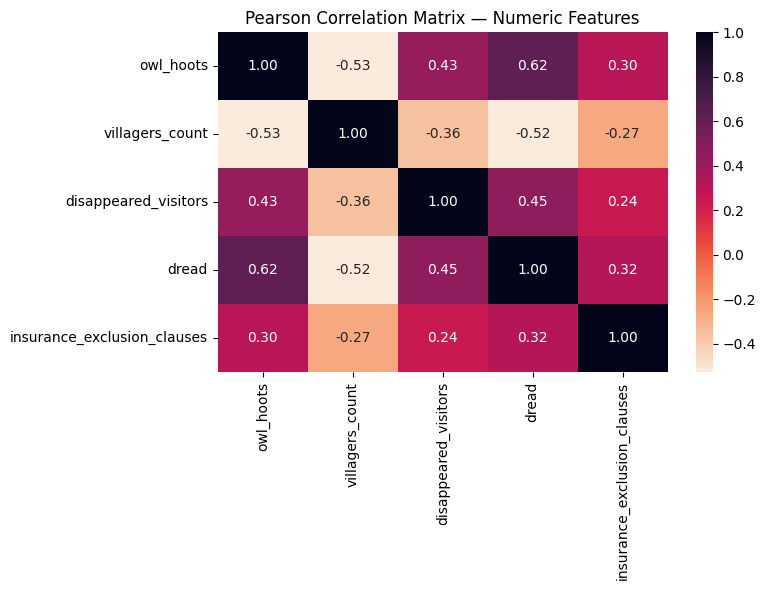

In [16]:
# Build a feature vector from numeric columns for the correlation computation
assembler_corr = VectorAssembler(inputCols=numeric_cols, outputCol="corr_features")
df_corr = assembler_corr.transform(properties).select("corr_features")

# Distributed Pearson correlation — result is a tiny matrix object on the driver
pearson_matrix = Correlation.corr(df_corr, "corr_features", "pearson").collect()[0][0]

# Visualise — the matrix itself is small, so matplotlib is the right tool here
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pearson_matrix.toArray(),
    annot=True, fmt=".2f",
    xticklabels=numeric_cols, yticklabels=numeric_cols,
    cmap=sns.cm.rocket_r, ax=ax
)
ax.set_title("Pearson Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [17]:
# 5.1a Property age: years elapsed since construction
CURRENT_YEAR = 2026
properties = properties.withColumn("property_age", lit(CURRENT_YEAR) - col("construction_date"))

# 5.1b Number of documented sightings
# 'sightings' is a pipe-delimited string — split on '|' to get an array, then count
properties = properties.withColumn("sightings_count", size(split(col("sightings"), r"\|")))

properties.select("construction_date", "property_age", "sightings", "sightings_count").show(4, truncate=40)

+-----------------+------------+-----------------------------+---------------+
|construction_date|property_age|                    sightings|sightings_count|
+-----------------+------------+-----------------------------+---------------+
|             1704|         322|1734|1797|1827|1886|1961|1985|              6|
|             1327|         699|               1505|1697|1892|              3|
|             1374|         652|1386|1406|1480|1612|1866|1920|              6|
|             1379|         647|     1698|1817|1826|1888|1935|              5|
+-----------------+------------+-----------------------------+---------------+
only showing top 4 rows


### 5.2 Encoding Categorical and Boolean Columns

Machine learning algorithms require numeric inputs. We apply three transformations in one cell:

- **StringIndexer** — maps each string category to an integer index ordered by frequency. Since Spark 3.0 it accepts multiple `inputCols`/`outputCols` pairs, so both categorical columns are indexed in a single `.fit().transform()` call.
- **OneHotEncoder** — converts those indices to sparse binary vectors, one dimension per category, eliminating any implied ordinal relationship.
- **Boolean and target casting** — `BooleanType` columns are cast to `IntegerType` (0/1); the `haunted` target likewise.

In [18]:
# StringIndexer accepts multiple column pairs in a single call (Spark 3.0+)
indexer = StringIndexer(
    inputCols     = ["phenomenon_type", "ghost"],
    outputCols    = ["phenomenon_idx",  "ghost_idx"],
    handleInvalid = "keep",
)
properties = indexer.fit(properties).transform(properties)

# OneHotEncoder: integer indices → sparse binary vectors
encoder = OneHotEncoder(
    inputCols  = ["phenomenon_idx", "ghost_idx"],
    outputCols = ["phenomenon_vec", "ghost_vec"],
)
properties = encoder.fit(properties).transform(properties)

# Boolean columns → IntegerType (0/1) for VectorAssembler compatibility
bool_cols = ["warning", "teenage_group_disappearance", "foggy", "belltower", "moor_nearby"]
for c in bool_cols:
    properties = properties.withColumn(c, col(c).cast(IntegerType()))

# Target column → IntegerType required by Spark ML classifiers
properties = properties.withColumn("haunted", col("haunted").cast(IntegerType()))

properties.select(["phenomenon_vec", "ghost_vec"] + bool_cols + ["haunted"]).show(3, truncate=60)

+--------------+---------------+-------+---------------------------+-----+---------+-----------+-------+
|phenomenon_vec|      ghost_vec|warning|teenage_group_disappearance|foggy|belltower|moor_nearby|haunted|
+--------------+---------------+-------+---------------------------+-----+---------+-----------+-------+
|(18,[2],[1.0])|(42,[39],[1.0])|      1|                          0|    0|        1|          0|      0|
|(18,[1],[1.0])|(42,[17],[1.0])|      1|                          1|    1|        0|          1|      0|
|(18,[0],[1.0])|(42,[29],[1.0])|      1|                          0|    0|        0|          1|      0|
+--------------+---------------+-------+---------------------------+-----+---------+-----------+-------+
only showing top 3 rows


### A Note on Dense and Sparse Vectors in Spark ML

At this point the DataFrame contains two kinds of vector columns and it is worth understanding the difference, because Spark ML uses both internally.

**Dense vector** — stores every element explicitly, even zeros. Represented as a contiguous array of `Double` values. Used when most elements are non-zero (e.g. the normalised numeric feature vector).

```
DenseVector([0.42, 1.87, 0.03, 0.91, ...])
```

**Sparse vector** — stores only the *non-zero* elements as `(index, value)` pairs, plus the total length. Used when most elements are zero — exactly the case after One-Hot Encoding, where only one position per category is 1 and all others are 0.

```
SparseVector(11, {2: 1.0})   # length 11, only index 2 is non-zero
```

**Why it matters:** `VectorAssembler` (next cell) accepts both types in its inputs and always produces a **dense** output vector. On a large dataset with many OHE categories this can blow up memory — in that case, pass `handleInvalid='keep'` and consider keeping the assembled vector sparse by using `setHandleInvalid` options or a custom assembler. For this dataset the vector is small enough that dense storage is fine.

You can inspect the type of any vector column with:

```python
from pyspark.ml.linalg import DenseVector, SparseVector
row = properties.select("phenomenon_vec").first()
print(type(row["phenomenon_vec"]))   # SparseVector
```

### 5.3 Feature Selection, Assembly, and Normalisation

`VectorAssembler` combines all selected columns into a single dense vector column required by Spark ML. We normalise the numeric sub-vector with L2 normalisation first, so that features with large absolute scales do not dominate distance-based computations, then assemble the final vector from the normalised numerics, boolean flags, and OHE vectors.

In [19]:
feature_cols_numeric     = [
    "property_age", "sightings_count",
    "owl_hoots", "villagers_count", "disappeared_visitors",
    "dread", "insurance_exclusion_clauses"]
feature_cols_boolean     = bool_cols
feature_cols_categorical = ["phenomenon_vec", "ghost_vec"]
TARGET = "haunted"

# Select only the columns entering the model
data = properties.select(
    feature_cols_numeric + feature_cols_boolean + feature_cols_categorical + [TARGET]
)

# Assemble numeric features, normalise, then build the final vector
assembler_num  = VectorAssembler(inputCols=feature_cols_numeric, outputCol="numeric_features")
normalizer     = Normalizer(inputCol="numeric_features", outputCol="numeric_features_norm", p=2.0)
assembler_all  = VectorAssembler(
    inputCols = ["numeric_features_norm"] + feature_cols_boolean + feature_cols_categorical,
    outputCol = "features")

data = assembler_num.transform(data)
data = normalizer.transform(data)
data = assembler_all.transform(data)

data.select("features", TARGET).show(3, truncate=80)

+--------------------------------------------------------------------------------+-------+
|                                                                        features|haunted|
+--------------------------------------------------------------------------------+-------+
|(72,[0,1,2,3,4,5,6,7,10,14,69],[0.5301387417811871,0.009878361648096655,0.091...|      0|
|(72,[0,1,2,3,4,5,7,8,9,11,13,47],[0.7829934840896414,0.0033604870561787185,0....|      0|
|(72,[0,1,2,3,4,5,6,7,11,12,59],[0.8685915447789568,0.007993173724959725,0.078...|      0|
+--------------------------------------------------------------------------------+-------+
only showing top 3 rows


## 6. Train / Test Split and Caching

**Caching.** After splitting we call `.cache()` on both halves. Without it, every pass an iterative algorithm makes through the training data re-evaluates the full transformation chain back to the source file. `.cache()` materialises each DataFrame in executor memory once, so subsequent passes are served from RAM. Always cache *after* all transformations are complete and *before* fitting.

In [20]:
training, test = [df.cache() for df in data.randomSplit([0.7, 0.3], seed=42)]

# Trigger materialisation now — cache is lazy until an action is called
training.count()
test.count()

training.groupBy(TARGET).count().orderBy(TARGET).show()
test.groupBy(TARGET).count().orderBy(TARGET).show()

+-------+-----+
|haunted|count|
+-------+-----+
|      0| 2929|
|      1|  450|
+-------+-----+

+-------+-----+
|haunted|count|
+-------+-----+
|      0| 1174|
|      1|  184|
+-------+-----+



## 7. Worked Example — Logistic Regression

See: [pyspark.ml.classification.LogisticRegression](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.classification.LogisticRegression.html)

In [21]:
# Step 1 — Fit
lr = LogisticRegression(featuresCol="features", labelCol=TARGET)
lr_model = lr.fit(training)

training_summary = lr_model.summary
print(f"Training AUC-ROC: {training_summary.areaUnderROC:.4f}")

Training AUC-ROC: 0.8798


In [22]:
# Step 2 — Evaluate on the held-out test set
evaluator = BinaryClassificationEvaluator(labelCol=TARGET)
auc_lr = evaluator.evaluate(lr_model.transform(test))
print(f"Test AUC-ROC (Logistic Regression): {auc_lr:.4f}")

Test AUC-ROC (Logistic Regression): 0.8515


### Reading the AUC-ROC

For HMSPIA, a high recall (few missed hauntings) matters more than high precision — mobilising a response team unnecessarily is preferable to leaving a Level 3 property unclassified.

> **Note on Big Data:** `training_summary.roc` is a small Spark DataFrame of (FPR, TPR) pairs, one per score threshold. Its size is bounded by the number of *distinct predicted scores*, not by the number of properties. Extracting it via `.collect()` is appropriate — the data brought to the driver is tiny regardless of dataset size.

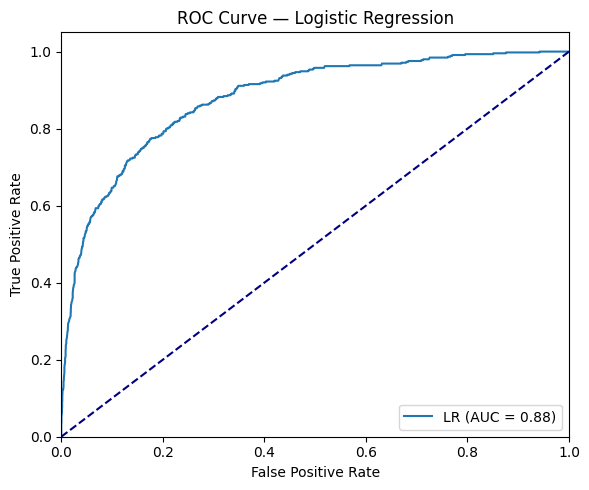

In [23]:
# Step 3a — ROC curve
# collect() is safe here: only O(thresholds) rows travel to the driver
roc_rows = training_summary.roc.select("FPR", "TPR").collect()
fpr_lr = [r["FPR"] for r in roc_rows]
tpr_lr = [r["TPR"] for r in roc_rows]

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC = {training_summary.areaUnderROC:.2f})")
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [24]:
# Step 3b — Feature importances via model coefficients
# lr_model.coefficients is a dense vector of length n_features — driver-side and small
for fname, coef in zip(feature_cols_numeric + feature_cols_boolean, lr_model.coefficients):
    print(f"  {fname:35s} {coef:+.4f}")

coef_labels = feature_cols_numeric + feature_cols_boolean
coef_values = [float(v) for v in lr_model.coefficients[: len(coef_labels)]]

# Data is already on the driver — sort and plot directly with Plotly
coef_pairs = sorted(zip(coef_labels, coef_values), key=lambda x: x[1])
sorted_labels, sorted_values = zip(*coef_pairs)

import plotly.graph_objs as go
fig = go.Figure(go.Bar(
    x=list(sorted_values),
    y=list(sorted_labels),
    orientation="h",
))
fig.update_layout(
    title="Logistic Regression — Feature Coefficients (positive → increases P(haunted))",
    xaxis_title="coefficient",
)
fig.show()

  property_age                        -1.0370
  sightings_count                     +24.2409
  owl_hoots                           -13.7315
  villagers_count                     -4.7273
  disappeared_visitors                +122.1183
  dread                               +26.3907
  insurance_exclusion_clauses         +34.2648
  warning                             +1.0190
  teenage_group_disappearance         +1.1714
  foggy                               +0.7805
  belltower                           +0.9321
  moor_nearby                         +0.7748


---
## 8. Exercise — Classifier Experimentation

The `evaluate_model()` helper below handles evaluation, ROC plotting, and result recording for any fitted Spark ML classifier. Run its cell first, then work through the exercises.


In [25]:
results = [("Logistic Regression", auc_lr)]

def evaluate_model(model_name, fitted_model, test_data, target_col, colour="steelblue", show_importances=True):
    """Evaluate a fitted Spark ML classifier and record results."""
    from sklearn.metrics import roc_curve, auc as sk_auc

    ev = BinaryClassificationEvaluator(labelCol=target_col)
    preds = fitted_model.transform(test_data)
    auc_score = ev.evaluate(preds)
    print(f"{model_name} — Test AUC-ROC: {auc_score:.4f}")

    rows = preds.select("probability", target_col).collect()
    probs  = [float(r["probability"][1]) for r in rows]
    labels = [r[target_col] for r in rows]
    fpr, tpr, _ = roc_curve(labels, probs)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color=colour, label=f"{model_name} (AUC = {auc_score:.2f})")
    plt.plot([0, 1], [0, 1], color="navy", linestyle="--")
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")
    plt.legend(loc="lower right")
    plt.tight_layout(); plt.show()

    if show_importances and hasattr(fitted_model, "featureImportances"):
        imp_labels = feature_cols_numeric + feature_cols_boolean
        imp_values = [float(v) for v in fitted_model.featureImportances.toArray()[: len(imp_labels)]]
        imp_pairs = sorted(zip(imp_labels, imp_values), key=lambda x: x[1])
        imp_sorted_labels, imp_sorted_values = zip(*imp_pairs)
        import plotly.graph_objs as _go
        _fig = _go.Figure(_go.Bar(x=list(imp_sorted_values), y=list(imp_sorted_labels), orientation="h"))
        _fig.update_layout(title=f"{model_name} — Feature Importances", xaxis_title="importance")
        _fig.show()

    results.append((model_name, round(auc_score, 4)))
    return fpr, tpr, auc_score

### 8.1 Decision Tree — tune `maxDepth`

Start with a single Decision Tree. It is the most interpretable classifier and serves as a baseline that shows what the ensemble methods improve upon.

Experiment with `maxDepth`. What happens to test AUC as you increase it? At what point does training AUC diverge from test AUC, and what does that tell you?

Decision Tree — Test AUC-ROC: 0.4460


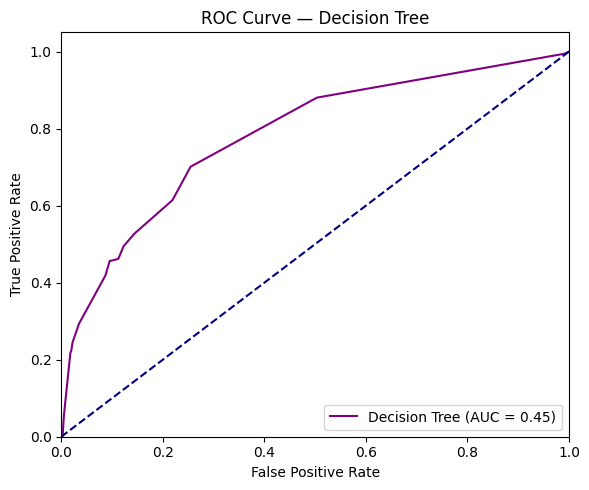

In [26]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    featuresCol = "features",
    labelCol    = TARGET,
    maxDepth    = 5,   # ← try: 2, 5, 10, 20
)
dt_model = dt.fit(training)
fpr_dt, tpr_dt, auc_dt = evaluate_model(
    model_name   = "Decision Tree",
    fitted_model = dt_model,
    test_data    = test,
    target_col   = TARGET,
    colour       = "purple",
)

### 8.2 Ensemble Methods — Random Forest and GBT

Both classifiers are imported for you. Fill in the missing import, instantiate each model, fit it, and call `evaluate_model()`.

**Random Forest:** experiment with `numTrees` and `maxDepth`. How does AUC change compared to the single Decision Tree above?

**Gradient-Boosted Trees:** `stepSize` (learning rate) and `maxIter` interact — a smaller step size generally needs more iterations to converge. Try halving `stepSize` and doubling `maxIter` together.

Random Forest — Test AUC-ROC: 0.8268


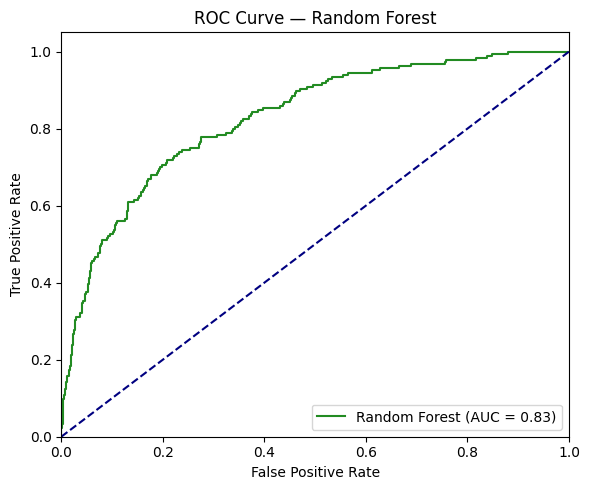

Gradient-Boosted Trees — Test AUC-ROC: 0.8456


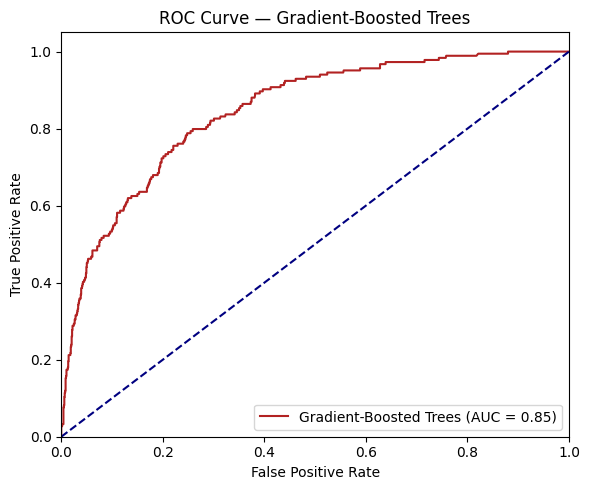

In [27]:
# SOLUTION
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier

# ── Random Forest ────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    featuresCol = "features",
    labelCol    = TARGET,
    numTrees    = 100,  # ← try: 10, 50, 100, 200
    maxDepth    = 5,    # ← try: 2, 5, 10
    seed        = 42,
)
rf_model = rf.fit(training)
fpr_rf, tpr_rf, auc_rf = evaluate_model(
    model_name   = "Random Forest",
    fitted_model = rf_model,
    test_data    = test,
    target_col   = TARGET,
    colour       = "forestgreen",
)

# ── Gradient-Boosted Trees ────────────────────────────────────────────────
gbt = GBTClassifier(
    featuresCol = "features",
    labelCol    = TARGET,
    maxIter     = 50,    # ← try: 5, 10, 50
    maxDepth    = 3,     # ← try: 2, 3, 5
    stepSize    = 0.05,  # ← try: 0.01, 0.05, 0.1, 0.3
    seed        = 42,
)
gbt_model = gbt.fit(training)
fpr_gbt, tpr_gbt, auc_gbt = evaluate_model(
    model_name   = "Gradient-Boosted Trees",
    fitted_model = gbt_model,
    test_data    = test,
    target_col   = TARGET,
    colour       = "firebrick",
)

### 8.3 Predicting from Text Features Only with TF-IDF

So far the model has used only structured columns. Here we go the other direction: can the free-text columns — `estate_agent_euphemism`, `cat_behaviour`, `vicar_response`, and `most_recent_excuse` — predict haunting *on their own*, without any numeric or boolean features?

A simple, embedding-free approach is **TF-IDF** (Term Frequency–Inverse Document Frequency), available natively in Spark ML:

1. **`Tokenizer`** — splits each string into a list of lowercase words.
2. **`HashingTF`** — maps each word to a bucket via hashing and counts occurrences per document. Produces a sparse vector.
3. **`IDF`** — down-weights words that appear in many documents (common words carry less signal). Produces a TF-IDF sparse vector.

We concatenate the TF-IDF vectors from all four text columns into a single `features` vector and train directly on that, with no structured features included.

Text-only feature vector: 2048 dimensions


26/04/19 13:04:57 WARN BlockManager: Asked to remove block broadcast_1049_piece0, which does not exist


GBT (Text Only) — Test AUC-ROC: 0.8647


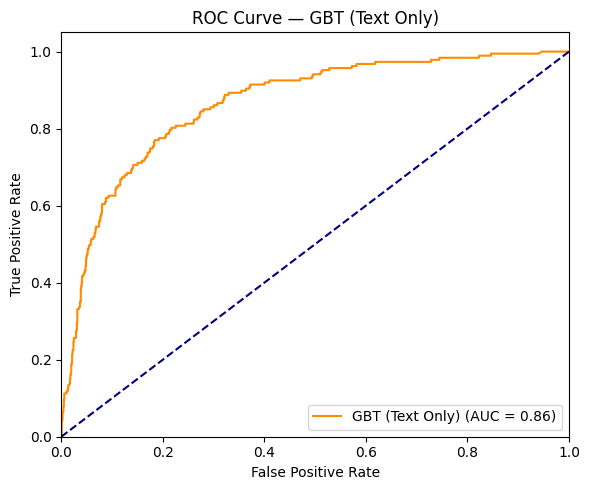

In [28]:
from pyspark.ml.feature import Tokenizer, HashingTF, IDF

TEXT_COLS = [
    "estate_agent_euphemism", "cat_behaviour",
    "vicar_response", "most_recent_excuse",
]

data_text = properties.select(TEXT_COLS + [TARGET])
tfidf_output_cols = []
for tc in TEXT_COLS:
    data_text = data_text.fillna("", subset=[tc])
    tokens_col = f"{tc}_tokens"
    tf_col     = f"{tc}_tf"
    tfidf_col  = f"{tc}_tfidf"

    tokenizer = Tokenizer(inputCol=tc, outputCol=tokens_col)
    hashing   = HashingTF(inputCol=tokens_col, outputCol=tf_col, numFeatures=512)
    idf       = IDF(inputCol=tf_col, outputCol=tfidf_col, minDocFreq=5)

    data_text = tokenizer.transform(data_text)
    data_text = hashing.transform(data_text)
    data_text = idf.fit(data_text).transform(data_text)
    tfidf_output_cols.append(tfidf_col)

assembler_text = VectorAssembler(inputCols=tfidf_output_cols, outputCol="features")

data_text_only = assembler_text.transform(data_text).select("features", TARGET)

print(f"Text-only feature vector: {data_text_only.select('features').first()[0].size} dimensions")

training_text, test_text = [df.cache() for df in data_text_only.randomSplit([0.7, 0.3], seed=42)]
training_text.count(); test_text.count()

# SOLUTION — use GBT as the best performer from Section 8.2
best_model = GBTClassifier(featuresCol="features", labelCol=TARGET,
                           maxIter=50, maxDepth=3, stepSize=0.05, seed=42)
best_fitted = best_model.fit(training_text)
fpr_text, tpr_text, auc_text = evaluate_model(
    "GBT (Text Only)", best_fitted, test_text, TARGET, colour="darkorange", show_importances=False
)

---
## 9. Model Comparison

Run the cells below to overlay all ROC curves and produce a ranked summary table.

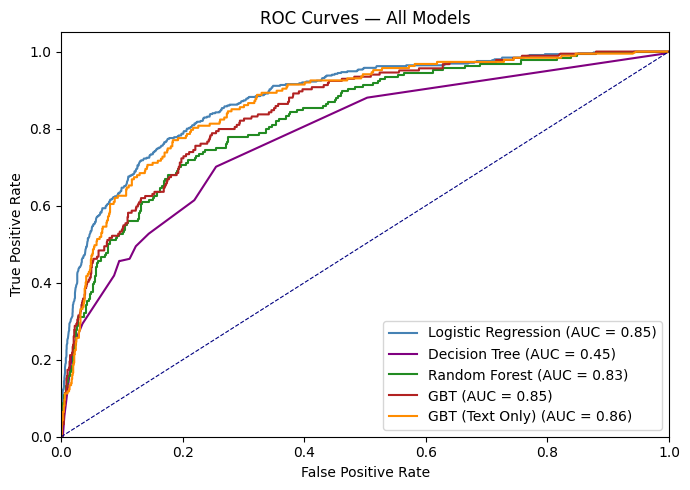

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(fpr_lr,   tpr_lr,   color="steelblue",   label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_dt,   tpr_dt,   color="purple",      label=f"Decision Tree (AUC = {auc_dt:.2f})")
plt.plot(fpr_rf,   tpr_rf,   color="forestgreen", label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_gbt,  tpr_gbt,  color="firebrick",   label=f"GBT (AUC = {auc_gbt:.2f})")
plt.plot(fpr_text, tpr_text, color="darkorange",  label=f"GBT (Text Only) (AUC = {auc_text:.2f})")

plt.plot([0, 1], [0, 1], color="navy", linestyle="--", linewidth=0.8)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [30]:
summary_df = spark.createDataFrame(results, ["Model", "AUC_ROC"]) \
    .orderBy("AUC_ROC", ascending=False)
summary_df.show(truncate=False)

+----------------------+------------------+
|Model                 |AUC_ROC           |
+----------------------+------------------+
|GBT (Text Only)       |0.8647            |
|Logistic Regression   |0.8514508184578891|
|Gradient-Boosted Trees|0.8456            |
|Random Forest         |0.8268            |
|Decision Tree         |0.446             |
+----------------------+------------------+

